# Bologna Transit Analysis - Step 00: Ingestione Dati e Layout Geografico

Questo notebook carica i dataset georeferenziati della rete di trasporto pubblico di **Bologna, Italia**.
Modelliamo la rete in **L-Space**:
- **Nodi**: Fermate della rete metropolitana di bus e banchine del tram.
- **Archi**: Connessioni dirette tra stazioni consecutive su una specifica linea.
- **Pesi**: Distanze fisiche calcolate con la formula dell'Haversine dalle coordinate geografiche.

Mettiamo a confronto la rete di **soli autobus (Bus Only)** con la futura rete integrata comprendente la **Linea Rossa e Linea Verde del Tram (Bus + Tram)**.

In [1]:
import sys
sys.path.append('..')
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from src.data_loader_bologna import load_bologna_network

## 1. Caricamento e Statistiche Generali delle Reti

In [2]:
G_bus, df_stations, df_connections, df_lines, df_demo = load_bologna_network(include_tram=False)
G_tram, _, _, _, _ = load_bologna_network(include_tram=True)

print("Rete Bus Only:")
print(f"  Nodi (Stazioni): {len(G_bus.nodes)}")
print(f"  Archi (Connessioni): {len(G_bus.edges)}")
print(f"  Densita': {nx.density(G_bus):.6f}")
print(f"  Connesso: {nx.is_connected(G_bus)}")

print("\nRete Bus + Tram:")
print(f"  Nodi (Stazioni): {len(G_tram.nodes)}")
print(f"  Archi (Connessioni): {len(G_tram.edges)}")
print(f"  Densita': {nx.density(G_tram):.6f}")
print(f"  Connesso: {nx.is_connected(G_tram)}")

Rete Bus Only:
  Nodi (Stazioni): 334
  Archi (Connessioni): 454
  Densita': 0.008164
  Connesso: True

Rete Bus + Tram:
  Nodi (Stazioni): 334
  Archi (Connessioni): 470
  Densita': 0.008452
  Connesso: True


## 2. Visualizzazione Geografica della Rete Integrata

Visualizziamo la mappa geografica delle linee principali di Bologna. I nodi quadrati blu rappresentano i campus dell'Università di Bologna (UNIBO).

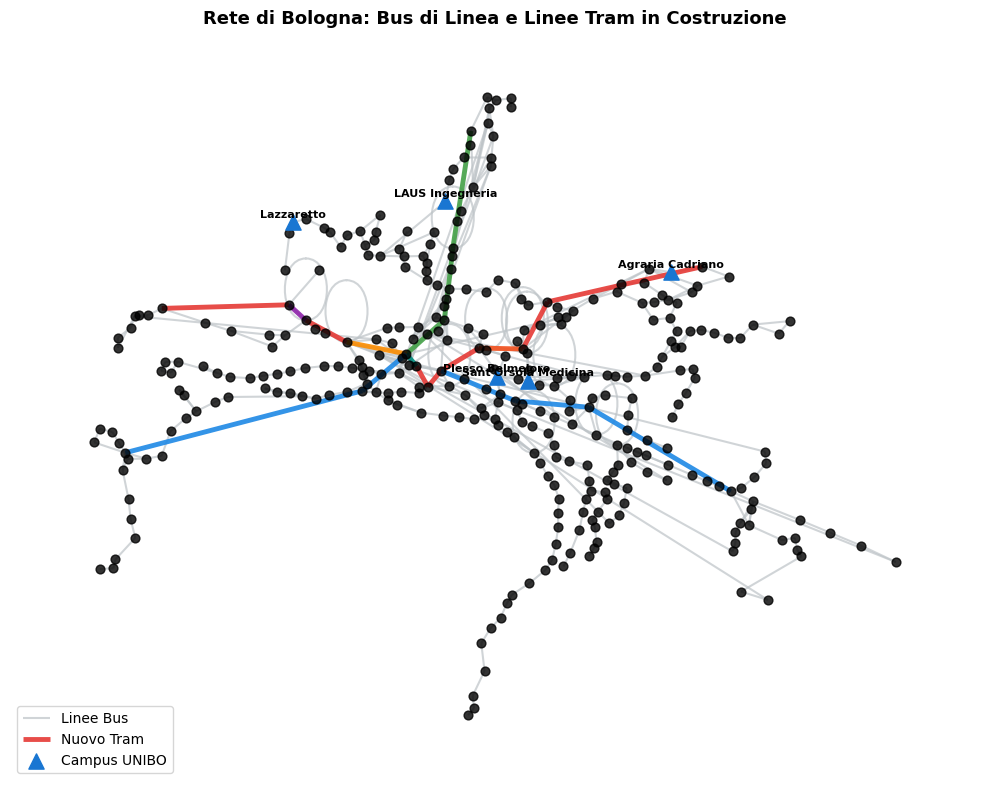

In [3]:
pos = {node: (data['lon'], data['lat']) for node, data in G_tram.nodes(data=True)}
line_colors_map = {int(row['line']): f"#{row['colour']}" for idx, row in df_lines.iterrows()}

plt.figure(figsize=(10, 8))
plt.gca().set_facecolor('#fdfefe')

# Disegna linee Bus
bus_edges = [(u, v) for u, v in G_tram.edges() if any(l < 100 for l in G_tram[u][v]['lines'])]
nx.draw_networkx_edges(G_tram, pos, edgelist=bus_edges, edge_color='#bdc3c7', width=1.5, alpha=0.7, label='Linee Bus')

# Disegna linee Tram
tram_edges = [(u, v) for u, v in G_tram.edges() if any(l >= 100 for l in G_tram[u][v]['lines'])]
tram_colors = [line_colors_map.get(G_tram[u][v]['lines'][0], '#C62828') for u, v in tram_edges]
nx.draw_networkx_edges(G_tram, pos, edgelist=tram_edges, edge_color=tram_colors, width=3.5, alpha=0.9, label='Nuovo Tram')

# Nodi
station_nodes = [node for node, data in G_tram.nodes(data=True) if data['type'] == 'Station']
campus_nodes = [node for node, data in G_tram.nodes(data=True) if data['type'] == 'Campus']

nx.draw_networkx_nodes(G_tram, pos, nodelist=station_nodes, node_size=40, node_color='black', alpha=0.8)
nx.draw_networkx_nodes(G_tram, pos, nodelist=campus_nodes, node_size=120, node_color='#1976D2', node_shape='^', label='Campus UNIBO')

campus_labels = {name: name for name in campus_nodes}
label_pos = {name: (pos[name][0], pos[name][1] + 0.0015) for name in campus_nodes}
nx.draw_networkx_labels(G_tram, label_pos, labels=campus_labels, font_size=8, font_weight='bold')

plt.title("Rete di Bologna: Bus di Linea e Linee Tram in Costruzione", fontsize=13, fontweight='bold')
plt.legend(loc='lower left')
plt.axis('off')
plt.tight_layout()
plt.show()